# Волновод
Точка $x$ с $(x,y)$, вектор $p$ с $(p,q)$ и $n=n(y)$
$$
\begin{cases}
    \frac{dx}{dt}=\frac{p}{n^2}, \frac{dp}{dt}=0 \\
    \frac{dy}{dt}=\frac{q}{n^2}, \frac{dq}{dt}=\frac{n'}{n}
\end{cases}
$$
Условие: $p^2+q^2=n^2(y)$


Пусть 
$$
n(y)=2\cos(y)+3
$$

$$
x(0)=0 \\
y(0)=0 \\
n(0)=5 \\
q(0)=\sqrt{25-p^2}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

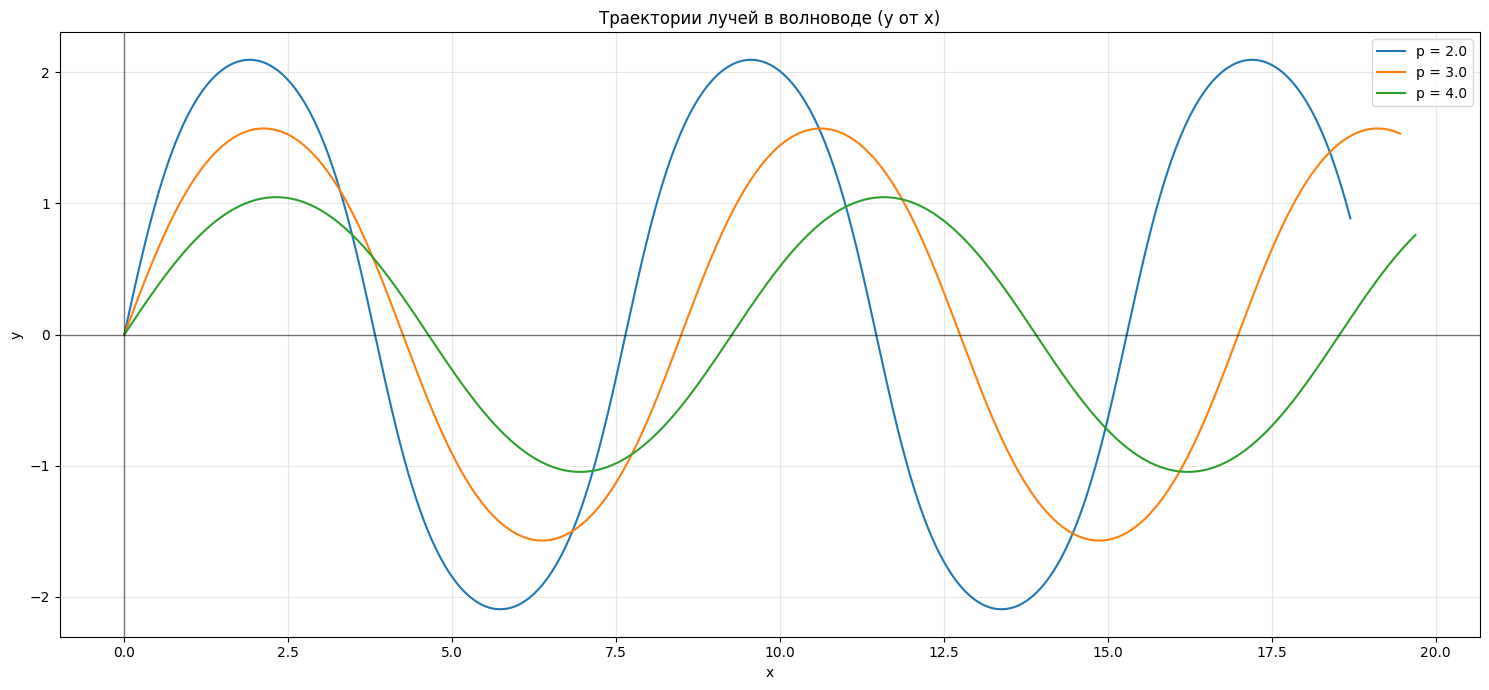

In [5]:
# Определение функции n(y) и её производной
def n_func(y):
    return 2 * np.cos(y) + 3

def n_prime_func(y):
    return -2 * np.sin(y)

# Система дифференциальных уравнений
def system(t, z, p):
    x, y, q = z
    n = n_func(y)
    n_prime = n_prime_func(y)
    
    dxdt = p / (n**2)
    dydt = q / (n**2)
    dqdt = n_prime / n
    
    return [dxdt, dydt, dqdt]

# Начальные условия
y0 = 0
x0 = 0
n0 = n_func(y0)

# Три разных значения p
p_values = [2.0, 3.0, 4.0]

# Время интегрирования
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 3000)

plt.figure(figsize=(15,7))
# Решение для каждого p
for p in p_values:
    # Начальное условие для q
    q0 = np.sqrt(n0**2 - p**2)
    
    # Решение системы
    sol = solve_ivp(system, t_span, [x0, y0, q0], args=(p,), 
                    t_eval=t_eval, method='RK45', rtol=1e-9, atol=1e-12)
    
    x = sol.y[0]
    y = sol.y[1]
    q = sol.y[2]
    
    # Это проверка точности решения
    n_values = n_func(y)
    invariant = p**2 + q**2 - n_values**2
    max_error = np.max(np.abs(invariant))
    
    # График y от x (траектория)
    plt.plot(x, y, label=f'p = {p}', linewidth=1.5)

# Добавление осей координат на первый график
plt.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)  # горизонтальная ось
plt.axvline(x=0, color='black', linewidth=1, linestyle='-', alpha=0.5)  # вертикальная ось

plt.xlabel('x')
plt.ylabel('y')
plt.title('Траектории лучей в волноводе (y от x)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()